In [1]:
import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from datasets import load_dataset
import spacy
import nltk
from nltk.corpus import stopwords

In [4]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

In [5]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
nlp=spacy.load("en_core_web_sm",disable=["ner"])

In [7]:
stop_words=set(stopwords.words("english"))

In [8]:
data=load_dataset("fancyzhx/yelp_polarity")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

In [9]:
train_df=data["train"].select(range(5000)).to_pandas()


In [10]:
train_df.head()

,text,label
0,"Unfortunately, the frustration of being Dr. Go...",0
1,Been going to Dr. Goldberg for over 10 years. ...,1
2,I don't know what Dr. Goldberg was like before...,0
3,I'm writing this review to give you a heads up...,0
4,All the food is great here. But the best thing...,1


In [11]:
train_df.columns

Index(['text', 'label'], dtype='object')

In [12]:
#cleaning
def clean_text(txt:str)->str:
  txt=str(txt)
  txt=html.unescape(txt)
  txt=txt.lower()
  txt=re.sub(r"http\S+|https\S+|www\S+"," ",txt)
  txt=re.sub(r"<.*?"," ",txt)
  txt=re.sub(r"@\w+"," ",txt)
  txt=re.sub(r"#\w+"," ",txt)
  txt=re.sub(r"[^a-z\s']"," ",txt)
  txt=re.sub(r"\s+"," ",txt).strip()
  return txt



In [13]:
#tokenization + stopword removal + lemmatization
def preprocess_text(text:str):
  cleaned_txt=clean_text(text)
  doc=nlp(cleaned_txt)
  tokens=[]
  for token in doc:
    lemma=token.lemma_.lower().strip()
    if not lemma:
      continue
    if not token.is_alpha:
      continue
    if lemma in stop_words:
      continue
    if len(lemma)<=2:
      continue
    tokens.append(lemma)
  return tokens," ".join(tokens)

In [14]:
train_df["tokens"],train_df["processed_text"]=zip(
    *train_df["text"].apply(preprocess_text)
)

In [15]:
print(train_df[["text","processed_text"]].head())

                                                text  \
0  Unfortunately, the frustration of being Dr. Go...   
1  Been going to Dr. Goldberg for over 10 years. ...   
2  I don't know what Dr. Goldberg was like before...   
3  I'm writing this review to give you a heads up...   
4  All the food is great here. But the best thing...   

                                      processed_text  
0  unfortunately frustration goldberg patient rep...  
1  goldberg year think one patient start mhmg gre...  
2  know goldberg like move arizona let tell stay ...  
3  write review give head see doctor office staff...  
4  food great good thing wing wing simply fantast...  


In [16]:
#vocabulary creation
count_vectorizer=CountVectorizer(min_df=2)
X_bow=count_vectorizer.fit_transform(train_df["processed_text"])
vocab=count_vectorizer.get_feature_names_out()
print("vocabulary size:",len(vocab))
print("sample vocab:",vocab[:20])

vocabulary size: 8631
sample vocab: ['aaa' 'aback' 'abandon' 'ability' 'able' 'abomination' 'abrasive'
 'abroad' 'abruptly' 'absence' 'absent' 'absolute' 'absolutely' 'absorb'
 'absurd' 'abundance' 'abundant' 'abuse' 'abusive' 'abysmal']


In [17]:
#Bag of Words/TF-IDF Vectors
tfidf_vectorizer=TfidfVectorizer(min_df=2)
X_tfidf=tfidf_vectorizer.fit_transform(train_df["processed_text"])


In [18]:
print("Bow Shape:",X_bow.shape)
print("TFIDF Shape",X_tfidf.shape)

Bow Shape: (5000, 8631)
TFIDF Shape (5000, 8631)


In [19]:
#word embeddings
sentences=train_df["tokens"].tolist()

In [20]:
w2v_model=Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10
)


In [21]:
w2v_model.vector_size

100

In [22]:
len(w2v_model.wv)

9002

In [23]:
#sentence embeddings
def sentence_embedding(tokens,model,vector_size=100):
  vectors=[]
  for tok in tokens:
    if tok in model.wv:
       vectors.append(model.wv[tok])
  if not vectors:
    return np.zeros(vector_size)
  return np.mean(vectors,axis=0)

In [24]:
sentence_embs=np.vstack([
    sentence_embedding(tokens,w2v_model,100) for tokens in train_df["tokens"]
])

In [25]:
sentence_embs.shape


(5000, 100)

In [27]:
#similarity search
def query_embedding(query:str):
  q_tokens,q_processed=preprocess_text(query)
  q_tfidf=tfidf_vectorizer.transform([q_processed])
  q_w2v=sentence_embedding(q_tokens,w2v_model,100).reshape(1,-1)
  return q_tfidf,q_w2v

In [28]:
def similar_comments(query,top_k=5,alpha=0.5):
  q_tfidf,q_w2v=query_embedding(query)
  tfidf_sim=cosine_similarity(q_tfidf,X_tfidf).flatten()
  w2v_sim=cosine_similarity(q_w2v,sentence_embs).flatten()
  combined_sim=(alpha*tfidf_sim)+(1-alpha)*w2v_sim
  best_score=combined_sim.argsort()[::-1][:top_k]
  results=[]
  for idx in best_score:
    results.append({
        "rank":len(results)+1,
        "text":train_df.iloc[idx]["text"],
        "score":float(combined_sim[idx]),
        "label":int(train_df.iloc[idx]["label"])
    })
  return pd.DataFrame(results)


In [31]:
#insights and visualization
#top terms from BOW
term_freq=np.asarray(X_bow.sum(axis=0)).ravel()
top_n=20
top_idx=term_freq.argsort()[-top_n:]

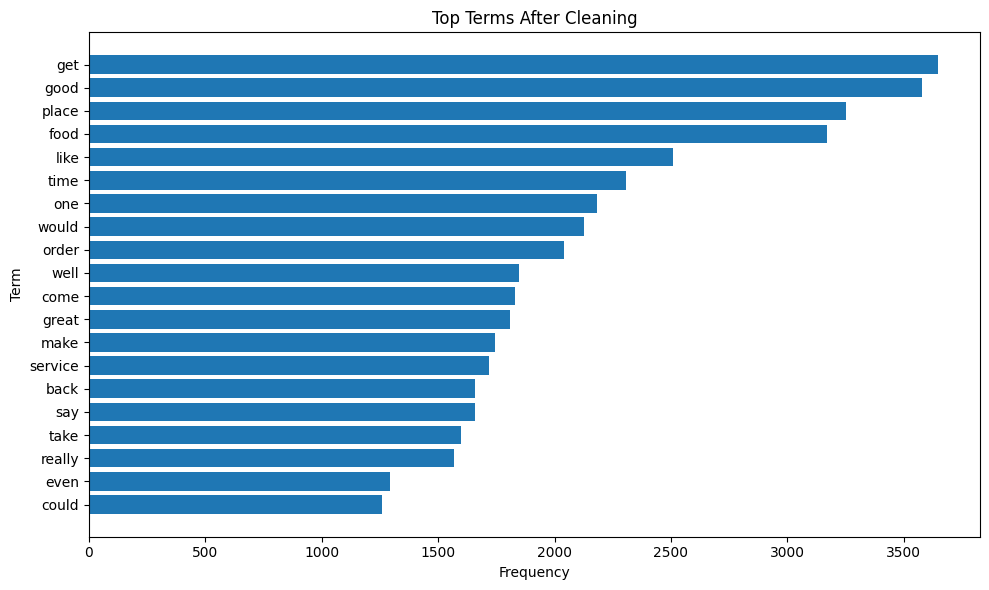

In [32]:
plt.figure(figsize=(10,6))
plt.barh([vocab[i] for i in top_idx],term_freq[top_idx])
plt.title("Top Terms After Cleaning")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

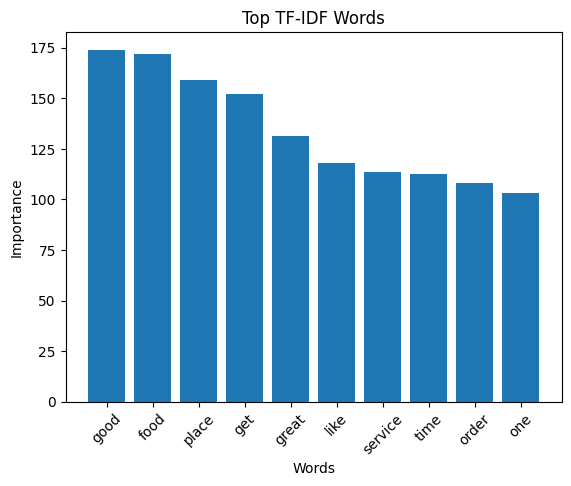

In [33]:
#TF-IDF important words
import numpy as np

tfidf_sum = np.asarray(X_tfidf.sum(axis=0)).flatten()
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()

top_indices = tfidf_sum.argsort()[::-1][:10]

top_words = [tfidf_vocab[i] for i in top_indices]
top_scores = tfidf_sum[top_indices]

plt.figure()
plt.bar(top_words, top_scores)
plt.xticks(rotation=45)
plt.title("Top TF-IDF Words")
plt.xlabel("Words")
plt.ylabel("Importance")
plt.show()

In [34]:
#PCA Visualization

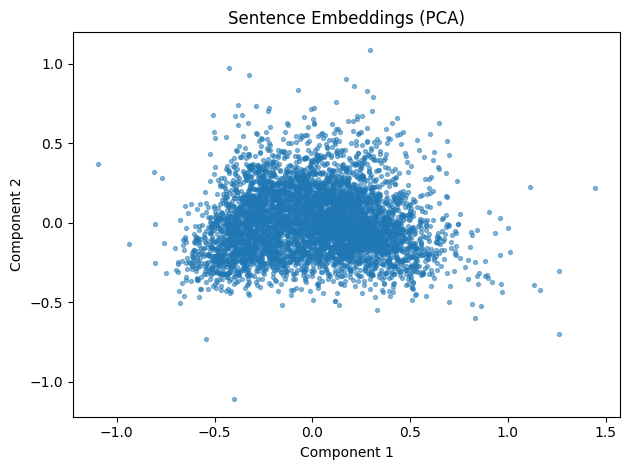

In [41]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
reduced=pca.fit_transform(sentence_embs)
plt.figure()
plt.scatter(reduced[:,0], reduced[:,1],s=8, alpha=0.5)
plt.title("Sentence Embeddings (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()


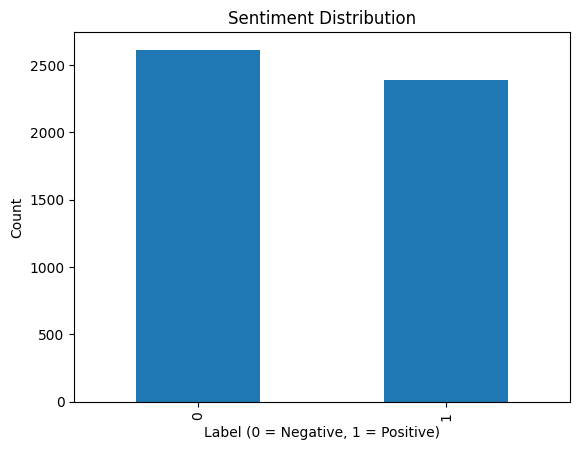

In [35]:
#sentiment distribution
train_df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Label (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()